# Movie Recommendation Engine - Collaborative Filtering

This notebook implements a movie recommendation engine using collaborative filtering techniques. We'll explore both user-based and item-based collaborative filtering approaches to recommend movies based on user preferences.

## 1. Import Libraries and Load Data

In [24]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import csr_matrix
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style('whitegrid')

print("Libraries imported successfully!")

Libraries imported successfully!


In [25]:
# Load the processed data

# Set dataset
dataset = 'ml-100k'

# Load datasets
movies_df = pd.read_csv(f'../movie-engine-data/processed/{dataset}/movies.csv')
ratings_df = pd.read_csv(f'../movie-engine-data/processed/{dataset}/ratings.csv')

print(f"Movies dataset shape: {movies_df.shape}")
print(f"Ratings dataset shape: {ratings_df.shape}")
print(f"\nNumber of unique users: {ratings_df['userId'].nunique()}")
print(f"Number of unique movies: {ratings_df['movieId'].nunique()}")
print(f"Total ratings: {len(ratings_df)}")
print(f"Rating sparsity: {(1 - len(ratings_df) / (ratings_df['userId'].nunique() * ratings_df['movieId'].nunique())) * 100:.2f}%")

Movies dataset shape: (9742, 21)
Ratings dataset shape: (100836, 4)

Number of unique users: 610
Number of unique movies: 9724
Total ratings: 100836
Rating sparsity: 98.30%


In [26]:
# Display sample data
print("Sample Movies:")
print(movies_df.head())
print("\nSample Ratings:")
print(ratings_df.head(10))

Sample Movies:
   movieId                               title  Action  Adventure  Animation  \
0        1                    Toy Story (1995)       0          1          1   
1        2                      Jumanji (1995)       0          1          0   
2        3             Grumpier Old Men (1995)       0          0          0   
3        4            Waiting to Exhale (1995)       0          0          0   
4        5  Father of the Bride Part II (1995)       0          0          0   

   Children  Comedy  Crime  Documentary  Drama  Fantasy  Film-Noir  Horror  \
0         1       1      0            0      0        1          0       0   
1         1       0      0            0      0        1          0       0   
2         0       1      0            0      0        0          0       0   
3         0       1      0            0      1        0          0       0   
4         0       1      0            0      0        0          0       0   

   Musical  Mystery  Romance  Sci-F

## 2. Exploratory Data Analysis

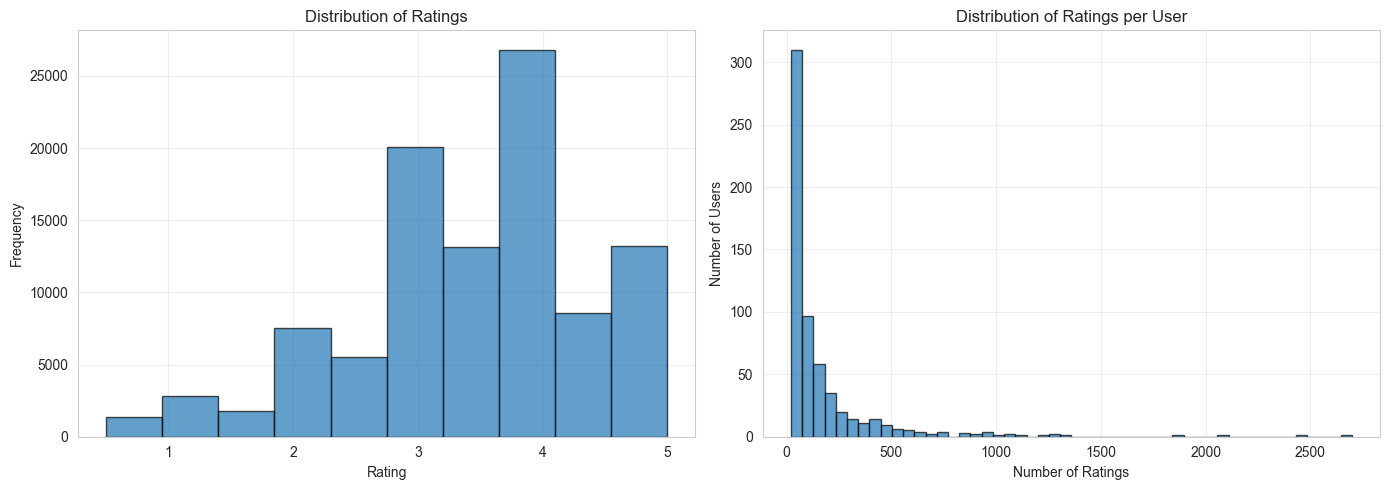

Rating statistics:
count    100836.000000
mean          3.501557
std           1.042529
min           0.500000
25%           3.000000
50%           3.500000
75%           4.000000
max           5.000000
Name: rating, dtype: float64


In [27]:
# Rating distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall rating distribution
axes[0].hist(ratings_df['rating'], bins=10, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Ratings')
axes[0].grid(True, alpha=0.3)

# Ratings per user
ratings_per_user = ratings_df.groupby('userId').size()
axes[1].hist(ratings_per_user, bins=50, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Number of Ratings')
axes[1].set_ylabel('Number of Users')
axes[1].set_title('Distribution of Ratings per User')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Rating statistics:")
print(ratings_df['rating'].describe())

## 3. Create User-Item Matrix

In [28]:
# Create user-item matrix (pivot table)
user_item_matrix = ratings_df.pivot_table(
    index='userId',
    columns='movieId',
    values='rating',
    fill_value=0
)

print(f"User-Item Matrix Shape: {user_item_matrix.shape}")
print(f"Matrix sparsity: {(user_item_matrix == 0).sum().sum() / (user_item_matrix.shape[0] * user_item_matrix.shape[1]) * 100:.2f}%")
print(f"\nSample of User-Item Matrix:")
user_item_matrix.iloc[:5, :5]

User-Item Matrix Shape: (610, 9724)
Matrix sparsity: 98.30%

Sample of User-Item Matrix:


movieId,1,2,3,4,5
userId,,,,,
1,4.0,0.0,4.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0
5,4.0,0.0,0.0,0.0,0.0


## 4. User-Based Collaborative Filtering

In [29]:
# Calculate user-user similarity matrix using cosine similarity
user_similarity = cosine_similarity(user_item_matrix)
user_similarity_df = pd.DataFrame(
    user_similarity,
    index=user_item_matrix.index,
    columns=user_item_matrix.index
)

print(f"User Similarity Matrix Shape: {user_similarity_df.shape}")
print(f"\nSample similarities for User 1:")
print(user_similarity_df.loc[1].sort_values(ascending=False).head(10))

User Similarity Matrix Shape: (610, 610)

Sample similarities for User 1:
userId
1      1.000000
266    0.357408
313    0.351562
368    0.345127
57     0.345034
91     0.334727
469    0.330664
39     0.329782
288    0.329700
452    0.328048
Name: 1, dtype: float64


In [30]:
def predict_user_based(user_id, movie_id, user_item_matrix, user_similarity_df, k=10):
    """
    Predict rating for a user-movie pair using user-based collaborative filtering
    
    Parameters:
    - user_id: ID of the user
    - movie_id: ID of the movie
    - user_item_matrix: User-item rating matrix
    - user_similarity_df: User similarity matrix
    - k: Number of similar users to consider
    
    Returns:
    - Predicted rating
    """
    if user_id not in user_item_matrix.index:
        return user_item_matrix[movie_id].mean() if movie_id in user_item_matrix.columns else 3.0
    
    if movie_id not in user_item_matrix.columns:
        return user_item_matrix.loc[user_id].mean() if user_item_matrix.loc[user_id].sum() > 0 else 3.0
    
    # Get similar users (excluding the user itself)
    similar_users = user_similarity_df[user_id].sort_values(ascending=False)[1:k+1]
    
    # Get ratings from similar users for this movie
    weighted_ratings = 0
    similarity_sum = 0
    
    for similar_user_id, similarity in similar_users.items():
        if similar_user_id in user_item_matrix.index:
            rating = user_item_matrix.loc[similar_user_id, movie_id]
            if rating > 0:  # Only consider users who have rated this movie
                weighted_ratings += similarity * rating
                similarity_sum += abs(similarity)
    
    if similarity_sum == 0:
        return user_item_matrix[movie_id].mean() if user_item_matrix[movie_id].sum() > 0 else 3.0
    
    predicted_rating = weighted_ratings / similarity_sum
    return np.clip(predicted_rating, 0.5, 5.0)  # Clip to valid rating range

# Test the function
test_user_id = 1
test_movie_id = 50
predicted_rating = predict_user_based(test_user_id, test_movie_id, user_item_matrix, user_similarity_df)
actual_rating = user_item_matrix.loc[test_user_id, test_movie_id]

print(f"User {test_user_id}, Movie {test_movie_id}:")
print(f"Predicted Rating: {predicted_rating:.2f}")
print(f"Actual Rating: {actual_rating}")

User 1, Movie 50:
Predicted Rating: 4.56
Actual Rating: 5.0


In [31]:
def recommend_movies_user_based(user_id, user_item_matrix, user_similarity_df, movies_df, n=10, k=10):
    """
    Recommend top N movies for a user using user-based collaborative filtering
    
    Parameters:
    - user_id: ID of the user
    - user_item_matrix: User-item rating matrix
    - user_similarity_df: User similarity matrix
    - movies_df: Movies dataframe with movie details
    - n: Number of recommendations to return
    - k: Number of similar users to consider
    
    Returns:
    - DataFrame with recommended movies and predicted ratings
    """
    if user_id not in user_item_matrix.index:
        # For new users, recommend popular movies
        popular_movies = ratings_df.groupby('movieId').agg({
            'rating': ['mean', 'count']
        }).reset_index()
        popular_movies.columns = ['movieId', 'avg_rating', 'rating_count']
        popular_movies = popular_movies[popular_movies['rating_count'] >= 50]
        popular_movies = popular_movies.sort_values('avg_rating', ascending=False).head(n)
        return movies_df[movies_df['movieId'].isin(popular_movies['movieId'])][['movieId', 'title']].merge(
            popular_movies[['movieId', 'avg_rating']], on='movieId'
        ).rename(columns={'avg_rating': 'predicted_rating'})
    
    # Get movies the user hasn't rated
    user_ratings = user_item_matrix.loc[user_id]
    unrated_movies = user_ratings[user_ratings == 0].index.tolist()
    
    # Predict ratings for unrated movies
    predictions = []
    for movie_id in unrated_movies:
        predicted_rating = predict_user_based(user_id, movie_id, user_item_matrix, user_similarity_df, k)
        predictions.append({
            'movieId': movie_id,
            'predicted_rating': predicted_rating
        })
    
    # Sort by predicted rating and get top N
    predictions_df = pd.DataFrame(predictions)
    predictions_df = predictions_df.sort_values('predicted_rating', ascending=False).head(n)
    
    # Merge with movie details
    recommendations = movies_df[['movieId', 'title']].merge(predictions_df, on='movieId')
    
    return recommendations

# Test recommendations
user_id = 1
recommendations = recommend_movies_user_based(user_id, user_item_matrix, user_similarity_df, movies_df, n=10)
print(f"\nTop 10 Movie Recommendations for User {user_id} (User-Based CF):")
print(recommendations)


Top 10 Movie Recommendations for User 1 (User-Based CF):
   movieId                                              title  \
0      720  Wallace & Gromit: The Best of Aardman Animatio...   
1      909                              Apartment, The (1960)   
2     1104                   Streetcar Named Desire, A (1951)   
3     1178                              Paths of Glory (1957)   
4     1227                 Once Upon a Time in America (1984)   
5     1228                                 Raging Bull (1980)   
6     1248                               Touch of Evil (1958)   
7     1284                              Big Sleep, The (1946)   
8     3972  Legend of Drunken Master, The (Jui kuen II) (1...   
9    57669                                   In Bruges (2008)   

   predicted_rating  
0               5.0  
1               5.0  
2               5.0  
3               5.0  
4               5.0  
5               5.0  
6               5.0  
7               5.0  
8               5.0  
9     

## 5. Item-Based Collaborative Filtering

In [32]:
# Calculate item-item similarity matrix using cosine similarity
# Transpose the user-item matrix to get item-user matrix
item_user_matrix = user_item_matrix.T

item_similarity = cosine_similarity(item_user_matrix)
item_similarity_df = pd.DataFrame(
    item_similarity,
    index=item_user_matrix.index,
    columns=item_user_matrix.index
)

print(f"Item Similarity Matrix Shape: {item_similarity_df.shape}")
print(f"\nSample similarities for Movie 1 (Toy Story):")
similar_to_toy_story = item_similarity_df.loc[1].sort_values(ascending=False)[1:11]
for movie_id, similarity in similar_to_toy_story.items():
    movie_title = movies_df[movies_df['movieId'] == movie_id]['title'].values[0]
    print(f"{movie_title}: {similarity:.4f}")

Item Similarity Matrix Shape: (9724, 9724)

Sample similarities for Movie 1 (Toy Story):
Toy Story 2 (1999): 0.5726
Jurassic Park (1993): 0.5656
Independence Day (a.k.a. ID4) (1996): 0.5643
Star Wars: Episode IV - A New Hope (1977): 0.5574
Forrest Gump (1994): 0.5471
Lion King, The (1994): 0.5411
Star Wars: Episode VI - Return of the Jedi (1983): 0.5411
Mission: Impossible (1996): 0.5389
Groundhog Day (1993): 0.5342
Back to the Future (1985): 0.5304


In [33]:
def predict_item_based(user_id, movie_id, user_item_matrix, item_similarity_df, k=10):
    """
    Predict rating for a user-movie pair using item-based collaborative filtering
    
    Parameters:
    - user_id: ID of the user
    - movie_id: ID of the movie
    - user_item_matrix: User-item rating matrix
    - item_similarity_df: Item similarity matrix
    - k: Number of similar items to consider
    
    Returns:
    - Predicted rating
    """
    if user_id not in user_item_matrix.index:
        return item_user_matrix.loc[movie_id].mean() if movie_id in item_user_matrix.index else 3.0
    
    if movie_id not in user_item_matrix.columns:
        return user_item_matrix.loc[user_id].mean() if user_item_matrix.loc[user_id].sum() > 0 else 3.0
    
    # Get movies rated by this user
    user_ratings = user_item_matrix.loc[user_id]
    rated_movies = user_ratings[user_ratings > 0]
    
    if len(rated_movies) == 0:
        return 3.0
    
    # Get similar movies
    similar_movies = item_similarity_df[movie_id].loc[rated_movies.index].sort_values(ascending=False)[:k]
    
    # Calculate weighted average
    weighted_ratings = 0
    similarity_sum = 0
    
    for similar_movie_id, similarity in similar_movies.items():
        rating = user_ratings[similar_movie_id]
        weighted_ratings += similarity * rating
        similarity_sum += abs(similarity)
    
    if similarity_sum == 0:
        return rated_movies.mean()
    
    predicted_rating = weighted_ratings / similarity_sum
    return np.clip(predicted_rating, 0.5, 5.0)

# Test the function
test_user_id = 1
test_movie_id = 100
predicted_rating = predict_item_based(test_user_id, test_movie_id, user_item_matrix, item_similarity_df)
actual_rating = user_item_matrix.loc[test_user_id, test_movie_id] if test_movie_id in user_item_matrix.columns else 0

print(f"User {test_user_id}, Movie {test_movie_id}:")
print(f"Predicted Rating: {predicted_rating:.2f}")
print(f"Actual Rating: {actual_rating}")

User 1, Movie 100:
Predicted Rating: 4.29
Actual Rating: 0.0


In [34]:
def recommend_movies_item_based(user_id, user_item_matrix, item_similarity_df, movies_df, n=10, k=10):
    """
    Recommend top N movies for a user using item-based collaborative filtering
    
    Parameters:
    - user_id: ID of the user
    - user_item_matrix: User-item rating matrix
    - item_similarity_df: Item similarity matrix
    - movies_df: Movies dataframe with movie details
    - n: Number of recommendations to return
    - k: Number of similar items to consider
    
    Returns:
    - DataFrame with recommended movies and predicted ratings
    """
    if user_id not in user_item_matrix.index:
        # For new users, recommend popular movies
        popular_movies = ratings_df.groupby('movieId').agg({
            'rating': ['mean', 'count']
        }).reset_index()
        popular_movies.columns = ['movieId', 'avg_rating', 'rating_count']
        popular_movies = popular_movies[popular_movies['rating_count'] >= 50]
        popular_movies = popular_movies.sort_values('avg_rating', ascending=False).head(n)
        return movies_df[movies_df['movieId'].isin(popular_movies['movieId'])][['movieId', 'title']].merge(
            popular_movies[['movieId', 'avg_rating']], on='movieId'
        ).rename(columns={'avg_rating': 'predicted_rating'})
    
    # Get movies the user hasn't rated
    user_ratings = user_item_matrix.loc[user_id]
    unrated_movies = user_ratings[user_ratings == 0].index.tolist()
    
    # Predict ratings for unrated movies
    predictions = []
    for movie_id in unrated_movies:
        predicted_rating = predict_item_based(user_id, movie_id, user_item_matrix, item_similarity_df, k)
        predictions.append({
            'movieId': movie_id,
            'predicted_rating': predicted_rating
        })
    
    # Sort by predicted rating and get top N
    predictions_df = pd.DataFrame(predictions)
    predictions_df = predictions_df.sort_values('predicted_rating', ascending=False).head(n)
    
    # Merge with movie details
    recommendations = movies_df[['movieId', 'title']].merge(predictions_df, on='movieId')
    
    return recommendations

# Test recommendations
user_id = 1
recommendations = recommend_movies_item_based(user_id, user_item_matrix, item_similarity_df, movies_df, n=10)
print(f"\nTop 10 Movie Recommendations for User {user_id} (Item-Based CF):")
print(recommendations)


Top 10 Movie Recommendations for User 1 (Item-Based CF):
   movieId                                      title  predicted_rating
0       13                               Balto (1995)               5.0
1     1284                      Big Sleep, The (1946)               5.0
2     1519                      Broken English (1996)               5.0
3    54286               Bourne Ultimatum, The (2007)               5.0
4    57669                           In Bruges (2008)               5.0
5   193579   Jon Stewart Has Left the Building (2015)               5.0
6   193581  Black Butler: Book of the Atlantic (2017)               5.0
7   193583               No Game No Life: Zero (2017)               5.0
8   193585                               Flint (2017)               5.0
9   193587        Bungo Stray Dogs: Dead Apple (2018)               5.0


## 6. Model Evaluation

In [35]:
# Split data into train and test sets
train_data, test_data = train_test_split(ratings_df, test_size=0.2, random_state=42)

print(f"Training set size: {len(train_data)}")
print(f"Test set size: {len(test_data)}")

# Create training user-item matrix
train_matrix = train_data.pivot_table(
    index='userId',
    columns='movieId',
    values='rating',
    fill_value=0
)

print(f"\nTraining matrix shape: {train_matrix.shape}")

Training set size: 80668
Test set size: 20168

Training matrix shape: (610, 8983)


In [36]:
# Recalculate similarity matrices for training data
train_user_similarity = cosine_similarity(train_matrix)
train_user_similarity_df = pd.DataFrame(
    train_user_similarity,
    index=train_matrix.index,
    columns=train_matrix.index
)

train_item_matrix = train_matrix.T
train_item_similarity = cosine_similarity(train_item_matrix)
train_item_similarity_df = pd.DataFrame(
    train_item_similarity,
    index=train_item_matrix.index,
    columns=train_item_matrix.index
)

print("Training similarity matrices computed successfully!")

Training similarity matrices computed successfully!


In [37]:
def evaluate_model(test_data, train_matrix, similarity_df, prediction_func, k=10, sample_size=1000):
    """
    Evaluate the recommendation model using RMSE and MAE
    
    Parameters:
    - test_data: Test ratings dataframe
    - train_matrix: Training user-item matrix
    - similarity_df: Similarity matrix (user or item based)
    - prediction_func: Prediction function to use
    - k: Number of neighbors to consider
    - sample_size: Number of test samples to evaluate (for speed)
    
    Returns:
    - Dictionary with RMSE and MAE scores
    """
    # Sample test data for faster evaluation
    test_sample = test_data.sample(n=min(sample_size, len(test_data)), random_state=42)
    
    predictions = []
    actuals = []
    
    for _, row in test_sample.iterrows():
        user_id = row['userId']
        movie_id = row['movieId']
        actual_rating = row['rating']
        
        # Skip if user or movie not in training set
        if user_id not in train_matrix.index or movie_id not in train_matrix.columns:
            continue
        
        predicted_rating = prediction_func(user_id, movie_id, train_matrix, similarity_df, k)
        
        predictions.append(predicted_rating)
        actuals.append(actual_rating)
    
    predictions = np.array(predictions)
    actuals = np.array(actuals)
    
    # Calculate metrics
    rmse = np.sqrt(np.mean((predictions - actuals) ** 2))
    mae = np.mean(np.abs(predictions - actuals))
    
    return {
        'RMSE': rmse,
        'MAE': mae,
        'num_predictions': len(predictions)
    }

def evaluate_hybrid_model(test_data, train_matrix, user_similarity_df, item_similarity_df, k=10, alpha=0.5, sample_size=1000):
    """
    Evaluate the hybrid recommendation model using RMSE and MAE
    
    Parameters:
    - test_data: Test ratings dataframe
    - train_matrix: Training user-item matrix
    - user_similarity_df: User similarity matrix
    - item_similarity_df: Item similarity matrix
    - k: Number of neighbors to consider
    - alpha: Weight for user-based predictions (1-alpha for item-based)
    - sample_size: Number of test samples to evaluate (for speed)
    
    Returns:
    - Dictionary with RMSE and MAE scores
    """
    # Sample test data for faster evaluation
    test_sample = test_data.sample(n=min(sample_size, len(test_data)), random_state=42)
    
    predictions = []
    actuals = []
    
    for _, row in test_sample.iterrows():
        user_id = row['userId']
        movie_id = row['movieId']
        actual_rating = row['rating']
        
        # Skip if user or movie not in training set
        if user_id not in train_matrix.index or movie_id not in train_matrix.columns:
            continue
        
        # Get predictions from both methods
        user_based_pred = predict_user_based(user_id, movie_id, train_matrix, user_similarity_df, k)
        item_based_pred = predict_item_based(user_id, movie_id, train_matrix, item_similarity_df, k)
        
        # Combine using weighted average
        hybrid_pred = alpha * user_based_pred + (1 - alpha) * item_based_pred
        
        predictions.append(hybrid_pred)
        actuals.append(actual_rating)
    
    predictions = np.array(predictions)
    actuals = np.array(actuals)
    
    # Calculate metrics
    rmse = np.sqrt(np.mean((predictions - actuals) ** 2))
    mae = np.mean(np.abs(predictions - actuals))
    
    return {
        'RMSE': rmse,
        'MAE': mae,
        'num_predictions': len(predictions)
    }

print("Evaluating User-Based Collaborative Filtering...")
user_based_metrics = evaluate_model(
    test_data, 
    train_matrix, 
    train_user_similarity_df, 
    predict_user_based,
    k=10,
    sample_size=1000
)

print(f"User-Based CF Metrics:")
print(f"  RMSE: {user_based_metrics['RMSE']:.4f}")
print(f"  MAE: {user_based_metrics['MAE']:.4f}")
print(f"  Predictions made: {user_based_metrics['num_predictions']}")

print("\nEvaluating Item-Based Collaborative Filtering...")
item_based_metrics = evaluate_model(
    test_data,
    train_matrix,
    train_item_similarity_df,
    predict_item_based,
    k=10,
    sample_size=1000
)

print(f"\nItem-Based CF Metrics:")
print(f"  RMSE: {item_based_metrics['RMSE']:.4f}")
print(f"  MAE: {item_based_metrics['MAE']:.4f}")
print(f"  Predictions made: {item_based_metrics['num_predictions']}")

print("\nEvaluating Hybrid Collaborative Filtering (50-50 blend)...")
hybrid_metrics = evaluate_hybrid_model(
    test_data,
    train_matrix,
    train_user_similarity_df,
    train_item_similarity_df,
    k=10,
    alpha=0.5,
    sample_size=1000
)

print(f"\nHybrid CF Metrics:")
print(f"  RMSE: {hybrid_metrics['RMSE']:.4f}")
print(f"  MAE: {hybrid_metrics['MAE']:.4f}")
print(f"  Predictions made: {hybrid_metrics['num_predictions']}")

Evaluating User-Based Collaborative Filtering...
User-Based CF Metrics:
  RMSE: 1.6874
  MAE: 1.2047
  Predictions made: 961

Evaluating Item-Based Collaborative Filtering...
User-Based CF Metrics:
  RMSE: 1.6874
  MAE: 1.2047
  Predictions made: 961

Evaluating Item-Based Collaborative Filtering...

Item-Based CF Metrics:
  RMSE: 0.8492
  MAE: 0.6501
  Predictions made: 961

Evaluating Hybrid Collaborative Filtering (50-50 blend)...

Item-Based CF Metrics:
  RMSE: 0.8492
  MAE: 0.6501
  Predictions made: 961

Evaluating Hybrid Collaborative Filtering (50-50 blend)...

Hybrid CF Metrics:
  RMSE: 1.0764
  MAE: 0.8179
  Predictions made: 961

Hybrid CF Metrics:
  RMSE: 1.0764
  MAE: 0.8179
  Predictions made: 961


## 7. Hybrid Recommendation System

In [38]:
def recommend_movies_hybrid(user_id, user_item_matrix, user_similarity_df, item_similarity_df, 
                           movies_df, n=10, k=10, alpha=0.5):
    """
    Hybrid recommendation combining user-based and item-based collaborative filtering
    
    Parameters:
    - user_id: ID of the user
    - user_item_matrix: User-item rating matrix
    - user_similarity_df: User similarity matrix
    - item_similarity_df: Item similarity matrix
    - movies_df: Movies dataframe with movie details
    - n: Number of recommendations to return
    - k: Number of neighbors to consider
    - alpha: Weight for user-based predictions (1-alpha for item-based)
    
    Returns:
    - DataFrame with recommended movies and predicted ratings
    """
    if user_id not in user_item_matrix.index:
        # For new users, recommend popular movies
        popular_movies = ratings_df.groupby('movieId').agg({
            'rating': ['mean', 'count']
        }).reset_index()
        popular_movies.columns = ['movieId', 'avg_rating', 'rating_count']
        popular_movies = popular_movies[popular_movies['rating_count'] >= 50]
        popular_movies = popular_movies.sort_values('avg_rating', ascending=False).head(n)
        return movies_df[movies_df['movieId'].isin(popular_movies['movieId'])][['movieId', 'title']].merge(
            popular_movies[['movieId', 'avg_rating']], on='movieId'
        ).rename(columns={'avg_rating': 'predicted_rating'})
    
    # Get movies the user hasn't rated
    user_ratings = user_item_matrix.loc[user_id]
    unrated_movies = user_ratings[user_ratings == 0].index.tolist()
    
    # Predict ratings using both methods
    predictions = []
    for movie_id in unrated_movies:
        user_based_pred = predict_user_based(user_id, movie_id, user_item_matrix, user_similarity_df, k)
        item_based_pred = predict_item_based(user_id, movie_id, user_item_matrix, item_similarity_df, k)
        
        # Combine predictions using weighted average
        hybrid_pred = alpha * user_based_pred + (1 - alpha) * item_based_pred
        
        predictions.append({
            'movieId': movie_id,
            'predicted_rating': hybrid_pred,
            'user_based': user_based_pred,
            'item_based': item_based_pred
        })
    
    # Sort by predicted rating and get top N
    predictions_df = pd.DataFrame(predictions)
    predictions_df = predictions_df.sort_values('predicted_rating', ascending=False).head(n)
    
    # Merge with movie details
    recommendations = movies_df[['movieId', 'title']].merge(
        predictions_df[['movieId', 'predicted_rating', 'user_based', 'item_based']], 
        on='movieId'
    )
    
    return recommendations

# Test hybrid recommendations
user_id = 1
hybrid_recommendations = recommend_movies_hybrid(
    user_id, 
    user_item_matrix, 
    user_similarity_df, 
    item_similarity_df, 
    movies_df, 
    n=10,
    alpha=0.5
)

print(f"\nTop 10 Hybrid Movie Recommendations for User {user_id}:")
print(hybrid_recommendations[['movieId', 'title', 'predicted_rating']].to_string(index=False))


Top 10 Hybrid Movie Recommendations for User 1:
 movieId                              title  predicted_rating
     909              Apartment, The (1960)          4.902745
    1227 Once Upon a Time in America (1984)          4.900089
    1284              Big Sleep, The (1946)          5.000000
    2067              Doctor Zhivago (1965)          4.902270
    3030                     Yojimbo (1961)          4.904463
    3037              Little Big Man (1970)          4.947539
    5502                       Signs (2002)          4.901702
    6287            Anger Management (2003)          4.949772
   54272         Simpsons Movie, The (2007)          4.953547
   57669                   In Bruges (2008)          5.000000


## 8. Interactive Recommendation Demo

In [39]:
def display_user_profile(user_id, user_item_matrix, movies_df, n=10):
    """
    Display a user's rating profile - their top rated movies
    """
    if user_id not in user_item_matrix.index:
        print(f"User {user_id} not found in the system.")
        return
    
    user_ratings = user_item_matrix.loc[user_id]
    rated_movies = user_ratings[user_ratings > 0].sort_values(ascending=False).head(n)
    
    print(f"\n{'='*80}")
    print(f"User {user_id}'s Top {n} Rated Movies:")
    print(f"{'='*80}")
    
    for movie_id, rating in rated_movies.items():
        movie_title = movies_df[movies_df['movieId'] == movie_id]['title'].values[0]
        print(f"  {movie_title}: {rating}")
    
    print(f"\nTotal movies rated: {(user_ratings > 0).sum()}")
    print(f"Average rating: {user_ratings[user_ratings > 0].mean():.2f}")

def get_recommendations_for_user(user_id, method='hybrid'):
    """
    Get and display recommendations for a user
    """
    print(f"\n{'='*80}")
    print(f"Generating Recommendations for User {user_id} using {method.upper()} method")
    print(f"{'='*80}")
    
    if method == 'user-based':
        recs = recommend_movies_user_based(user_id, user_item_matrix, user_similarity_df, movies_df, n=10)
    elif method == 'item-based':
        recs = recommend_movies_item_based(user_id, user_item_matrix, item_similarity_df, movies_df, n=10)
    else:  # hybrid
        recs = recommend_movies_hybrid(user_id, user_item_matrix, user_similarity_df, 
                                      item_similarity_df, movies_df, n=10, alpha=0.5)
    
    print("\nTop 10 Recommended Movies:")
    for idx, row in recs.iterrows():
        print(f"  {row['title']}: {row['predicted_rating']:.2f}")
    
    return recs

# Demo: Show profile and recommendations for a sample user
sample_user_id = 7
display_user_profile(sample_user_id, user_item_matrix, movies_df, n=10)
recommendations = get_recommendations_for_user(sample_user_id, method='hybrid')


User 7's Top 10 Rated Movies:
  Forrest Gump (1994): 5.0
  Star Wars: Episode IV - A New Hope (1977): 5.0
  Jurassic Park (1993): 5.0
  Hot Shots! Part Deux (1993): 5.0
  Silence of the Lambs, The (1991): 5.0
  Back to the Future (1985): 5.0
  Terminator, The (1984): 5.0
  Psycho (1960): 5.0
  Naked Gun 2 1/2: The Smell of Fear, The (1991): 5.0
  Spirited Away (Sen to Chihiro no kamikakushi) (2001): 5.0

Total movies rated: 152
Average rating: 3.23

Generating Recommendations for User 7 using HYBRID method

Top 10 Recommended Movies:
  Pulp Fiction (1994): 4.42
  Shawshank Redemption, The (1994): 4.60
  Wallace & Gromit: A Close Shave (1995): 4.53
  Casablanca (1942): 4.60
  Goodfellas (1990): 4.48
  Cool Hand Luke (1967): 4.45
  Ben-Hur (1959): 4.50
  Star Trek: First Contact (1996): 4.59
  Snakes on a Plane (2006): 4.43
  Avatar (2009): 4.44

Top 10 Recommended Movies:
  Pulp Fiction (1994): 4.42
  Shawshank Redemption, The (1994): 4.60
  Wallace & Gromit: A Close Shave (1995): 4.53

## 9. Similar Movies Finder

In [40]:
def find_similar_movies(movie_title, item_similarity_df, movies_df, n=10):
    """
    Find movies similar to a given movie based on item-based collaborative filtering
    
    Parameters:
    - movie_title: Title of the movie (can be partial match)
    - item_similarity_df: Item similarity matrix
    - movies_df: Movies dataframe
    - n: Number of similar movies to return
    
    Returns:
    - DataFrame with similar movies and similarity scores
    """
    # Find the movie
    matching_movies = movies_df[movies_df['title'].str.contains(movie_title, case=False, na=False)]
    
    if len(matching_movies) == 0:
        print(f"No movies found matching '{movie_title}'")
        return None
    
    if len(matching_movies) > 1:
        print(f"Multiple movies found matching '{movie_title}':")
        for idx, row in matching_movies.iterrows():
            print(f"  {row['movieId']}: {row['title']}")
        print("\nUsing the first match. Please be more specific if needed.")
    
    movie_id = matching_movies.iloc[0]['movieId']
    movie_name = matching_movies.iloc[0]['title']
    
    print(f"\n{'='*80}")
    print(f"Finding movies similar to: {movie_name}")
    print(f"{'='*80}")
    
    # Get similar movies
    if movie_id not in item_similarity_df.columns:
        print(f"Movie {movie_name} not found in similarity matrix (may have no ratings).")
        return None
    
    similar_movies = item_similarity_df[movie_id].sort_values(ascending=False)[1:n+1]
    
    # Create results dataframe
    results = []
    for sim_movie_id, similarity in similar_movies.items():
        movie_info = movies_df[movies_df['movieId'] == sim_movie_id]
        if len(movie_info) > 0:
            results.append({
                'movieId': sim_movie_id,
                'title': movie_info.iloc[0]['title'],
                'similarity': similarity
            })
    
    results_df = pd.DataFrame(results)
    
    print(f"\nTop {n} Similar Movies:")
    for idx, row in results_df.iterrows():
        print(f"  {row['title']}: {row['similarity']:.4f}")
    
    return results_df

# Example: Find movies similar to "Toy Story"
similar_to_toy_story = find_similar_movies("Toy Story", item_similarity_df, movies_df, n=10)

Multiple movies found matching 'Toy Story':
  1: Toy Story (1995)
  3114: Toy Story 2 (1999)
  78499: Toy Story 3 (2010)

Using the first match. Please be more specific if needed.

Finding movies similar to: Toy Story (1995)

Top 10 Similar Movies:
  Toy Story 2 (1999): 0.5726
  Jurassic Park (1993): 0.5656
  Independence Day (a.k.a. ID4) (1996): 0.5643
  Star Wars: Episode IV - A New Hope (1977): 0.5574
  Forrest Gump (1994): 0.5471
  Lion King, The (1994): 0.5411
  Star Wars: Episode VI - Return of the Jedi (1983): 0.5411
  Mission: Impossible (1996): 0.5389
  Groundhog Day (1993): 0.5342
  Back to the Future (1985): 0.5304


In [41]:
# Try finding similar movies for other popular titles
print("\n" + "="*80)
similar_to_matrix = find_similar_movies("Matrix", item_similarity_df, movies_df, n=5)

print("\n" + "="*80)
similar_to_star_wars = find_similar_movies("Star Wars", item_similarity_df, movies_df, n=5)


Multiple movies found matching 'Matrix':
  2571: Matrix, The (1999)
  6365: Matrix Reloaded, The (2003)
  6934: Matrix Revolutions, The (2003)
  27660: Animatrix, The (2003)

Using the first match. Please be more specific if needed.

Finding movies similar to: Matrix, The (1999)

Top 5 Similar Movies:
  Fight Club (1999): 0.7139
  Star Wars: Episode V - The Empire Strikes Back (1980): 0.7009
  Saving Private Ryan (1998): 0.6796
  Star Wars: Episode IV - A New Hope (1977): 0.6634
  Star Wars: Episode VI - Return of the Jedi (1983): 0.6610

Multiple movies found matching 'Star Wars':
  260: Star Wars: Episode IV - A New Hope (1977)
  1196: Star Wars: Episode V - The Empire Strikes Back (1980)
  1210: Star Wars: Episode VI - Return of the Jedi (1983)
  2628: Star Wars: Episode I - The Phantom Menace (1999)
  5378: Star Wars: Episode II - Attack of the Clones (2002)
  33493: Star Wars: Episode III - Revenge of the Sith (2005)
  61160: Star Wars: The Clone Wars (2008)
  79006: Empire of Dr

## 10. Model Comparison and Analysis

In [42]:
# Compare all three methods for the same user
def compare_methods(user_id, n=5):
    """
    Compare recommendations from all three methods for a given user
    """
    print(f"\n{'='*80}")
    print(f"Comparing Recommendation Methods for User {user_id}")
    print(f"{'='*80}")
    
    # User-based recommendations
    user_based = recommend_movies_user_based(user_id, user_item_matrix, user_similarity_df, movies_df, n=n)
    print(f"\nUser-Based Collaborative Filtering:")
    for idx, row in user_based.iterrows():
        print(f"  {row['title']}: {row['predicted_rating']:.2f}")
    
    # Item-based recommendations
    item_based = recommend_movies_item_based(user_id, user_item_matrix, item_similarity_df, movies_df, n=n)
    print(f"\nItem-Based Collaborative Filtering:")
    for idx, row in item_based.iterrows():
        print(f"  {row['title']}: {row['predicted_rating']:.2f}")
    
    # Hybrid recommendations
    hybrid = recommend_movies_hybrid(user_id, user_item_matrix, user_similarity_df, 
                                    item_similarity_df, movies_df, n=n, alpha=0.5)
    print(f"\nHybrid Method (50-50 blend):")
    for idx, row in hybrid.iterrows():
        print(f"  {row['title']}: {row['predicted_rating']:.2f}")
    
    return {
        'user_based': user_based,
        'item_based': item_based,
        'hybrid': hybrid
    }

# Compare methods for a sample user
comparison = compare_methods(5, n=5)


Comparing Recommendation Methods for User 5

User-Based Collaborative Filtering:
  Leaving Las Vegas (1995): 5.00
  Boys on the Side (1995): 5.00
  Murder in the First (1995): 5.00
  Léon: The Professional (a.k.a. The Professional) (Léon) (1994): 5.00
  Specialist, The (1994): 5.00

User-Based Collaborative Filtering:
  Leaving Las Vegas (1995): 5.00
  Boys on the Side (1995): 5.00
  Murder in the First (1995): 5.00
  Léon: The Professional (a.k.a. The Professional) (Léon) (1994): 5.00
  Specialist, The (1994): 5.00

Item-Based Collaborative Filtering:
  Harmonists, The (1997): 5.00
  Dancemaker (1998): 5.00
  Trippin' (1999): 5.00
  Alien Contamination (1980): 5.00
  61* (2001): 5.00

Item-Based Collaborative Filtering:
  Harmonists, The (1997): 5.00
  Dancemaker (1998): 5.00
  Trippin' (1999): 5.00
  Alien Contamination (1980): 5.00
  61* (2001): 5.00

Hybrid Method (50-50 blend):
  Leaving Las Vegas (1995): 4.48
  Circle of Friends (1995): 4.28
  Immortal Beloved (1994): 4.33
  Jun

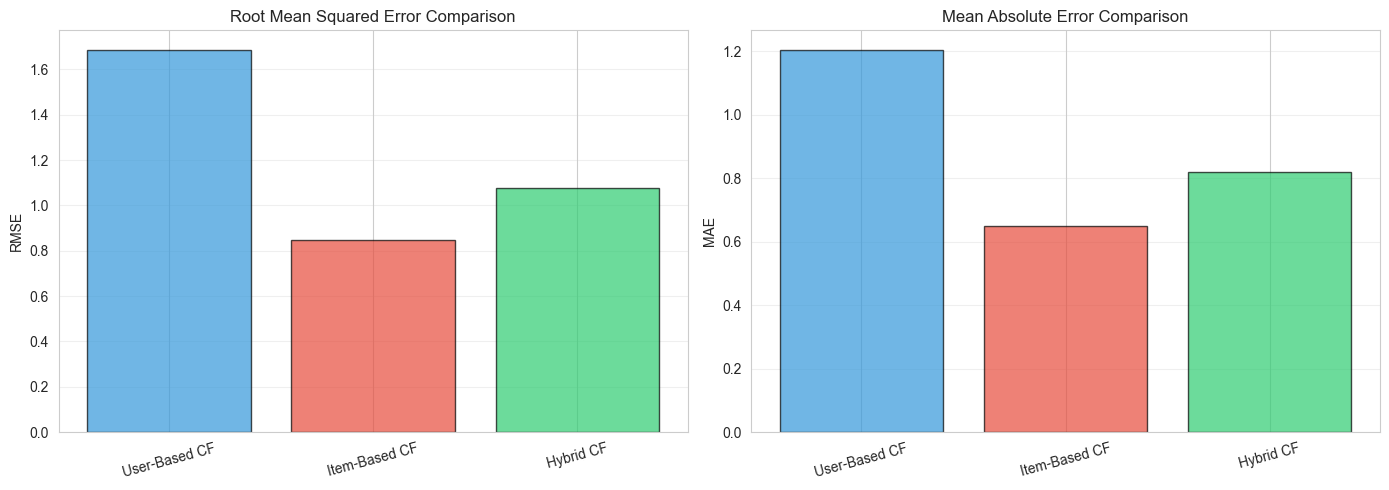


Model Performance Summary:
       Method     RMSE      MAE
User-Based CF 1.687441 1.204711
Item-Based CF 0.849170 0.650124
    Hybrid CF 1.076374 0.817856

Lower RMSE and MAE values indicate better performance
Best RMSE: Item-Based CF
Best MAE: Item-Based CF


In [43]:
# Visualize model performance comparison
metrics_comparison = pd.DataFrame({
    'Method': ['User-Based CF', 'Item-Based CF', 'Hybrid CF'],
    'RMSE': [user_based_metrics['RMSE'], item_based_metrics['RMSE'], hybrid_metrics['RMSE']],
    'MAE': [user_based_metrics['MAE'], item_based_metrics['MAE'], hybrid_metrics['MAE']]
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RMSE comparison
axes[0].bar(metrics_comparison['Method'], metrics_comparison['RMSE'], 
            color=['#3498db', '#e74c3c', '#2ecc71'], alpha=0.7, edgecolor='black')
axes[0].set_ylabel('RMSE')
axes[0].set_title('Root Mean Squared Error Comparison')
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].tick_params(axis='x', rotation=15)

# MAE comparison
axes[1].bar(metrics_comparison['Method'], metrics_comparison['MAE'], 
            color=['#3498db', '#e74c3c', '#2ecc71'], alpha=0.7, edgecolor='black')
axes[1].set_ylabel('MAE')
axes[1].set_title('Mean Absolute Error Comparison')
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

print("\nModel Performance Summary:")
print(metrics_comparison.to_string(index=False))
print("\n" + "="*60)
print("Lower RMSE and MAE values indicate better performance")
best_rmse = metrics_comparison.loc[metrics_comparison['RMSE'].idxmin(), 'Method']
best_mae = metrics_comparison.loc[metrics_comparison['MAE'].idxmin(), 'Method']
print(f"Best RMSE: {best_rmse}")
print(f"Best MAE: {best_mae}")

## 11. Summary and Conclusions

### Key Findings:

1. **User-Based Collaborative Filtering**:
   - Recommends movies based on similar users' preferences
   - Works well when users have similar taste patterns
   - Can suffer from scalability issues with large user bases

2. **Item-Based Collaborative Filtering**:
   - Recommends movies based on similarity between items
   - More stable over time as item relationships change less frequently
   - Generally performs better with sparse datasets

3. **Hybrid Approach**:
   - Combines strengths of both methods
   - Can provide more robust recommendations
   - Adjustable weighting allows for customization

### Practical Applications:

- **New Users (Cold Start)**: Recommend popular movies until sufficient data is collected
- **Similar Movie Discovery**: Use item-based similarity to find related content
- **Personalized Recommendations**: Use hybrid approach for best overall performance

### Next Steps:

- Implement matrix factorization techniques (SVD, ALS)
- Add content-based filtering using movie genres
- Incorporate temporal dynamics (time-aware recommendations)
- Implement deep learning approaches (Neural Collaborative Filtering)
- Add diversity and serendipity metrics to recommendations

## 12. Production-Ready Model Class

To use this in an application, we need to package it as a reusable class that can be trained, saved, and loaded.

In [ ]:
import pickle
import json
from datetime import datetime

class HybridRecommender:
    """
    Production-ready hybrid collaborative filtering recommender system
    
    This class combines user-based and item-based collaborative filtering
    to provide movie recommendations. It can be trained, saved, and loaded
    for use in production applications.
    """
    
    def __init__(self, alpha=0.5, k=10):
        """
        Initialize the recommender
        
        Parameters:
        - alpha: Weight for user-based predictions (1-alpha for item-based)
        - k: Number of neighbors to consider
        """
        self.alpha = alpha
        self.k = k
        self.user_item_matrix = None
        self.user_similarity_df = None
        self.item_similarity_df = None
        self.movies_df = None
        self.is_trained = False
        self.metadata = {}
        
    def fit(self, ratings_df, movies_df):
        """
        Train the recommender on ratings data
        
        Parameters:
        - ratings_df: DataFrame with columns [userId, movieId, rating]
        - movies_df: DataFrame with movie information
        """
        print("Training hybrid recommender...")
        
        # Store movies dataframe
        self.movies_df = movies_df.copy()
        
        # Create user-item matrix
        print("  Creating user-item matrix...")
        self.user_item_matrix = ratings_df.pivot_table(
            index='userId',
            columns='movieId',
            values='rating',
            fill_value=0
        )
        
        # Calculate user similarity
        print("  Calculating user similarity matrix...")
        user_similarity = cosine_similarity(self.user_item_matrix)
        self.user_similarity_df = pd.DataFrame(
            user_similarity,
            index=self.user_item_matrix.index,
            columns=self.user_item_matrix.index
        )
        
        # Calculate item similarity
        print("  Calculating item similarity matrix...")
        item_user_matrix = self.user_item_matrix.T
        item_similarity = cosine_similarity(item_user_matrix)
        self.item_similarity_df = pd.DataFrame(
            item_similarity,
            index=item_user_matrix.index,
            columns=item_user_matrix.index
        )
        
        # Store metadata
        self.metadata = {
            'train_date': datetime.now().isoformat(),
            'num_users': len(self.user_item_matrix),
            'num_movies': len(self.user_item_matrix.columns),
            'num_ratings': len(ratings_df),
            'alpha': self.alpha,
            'k': self.k,
            'sparsity': (self.user_item_matrix == 0).sum().sum() / 
                       (self.user_item_matrix.shape[0] * self.user_item_matrix.shape[1])
        }
        
        self.is_trained = True
        print(f"  Training complete!")
        print(f"  Users: {self.metadata['num_users']}")
        print(f"  Movies: {self.metadata['num_movies']}")
        print(f"  Ratings: {self.metadata['num_ratings']}")
        
        return self
    
    def _predict_user_based(self, user_id, movie_id):
        """Predict rating using user-based CF"""
        if user_id not in self.user_item_matrix.index:
            return self.user_item_matrix[movie_id].mean() if movie_id in self.user_item_matrix.columns else 3.0
        
        if movie_id not in self.user_item_matrix.columns:
            return self.user_item_matrix.loc[user_id].mean() if self.user_item_matrix.loc[user_id].sum() > 0 else 3.0
        
        similar_users = self.user_similarity_df[user_id].sort_values(ascending=False)[1:self.k+1]
        
        weighted_ratings = 0
        similarity_sum = 0
        
        for similar_user_id, similarity in similar_users.items():
            if similar_user_id in self.user_item_matrix.index:
                rating = self.user_item_matrix.loc[similar_user_id, movie_id]
                if rating > 0:
                    weighted_ratings += similarity * rating
                    similarity_sum += abs(similarity)
        
        if similarity_sum == 0:
            return self.user_item_matrix[movie_id].mean() if self.user_item_matrix[movie_id].sum() > 0 else 3.0
        
        predicted_rating = weighted_ratings / similarity_sum
        return np.clip(predicted_rating, 0.5, 5.0)
    
    def _predict_item_based(self, user_id, movie_id):
        """Predict rating using item-based CF"""
        if user_id not in self.user_item_matrix.index:
            return self.user_item_matrix.T.loc[movie_id].mean() if movie_id in self.user_item_matrix.columns else 3.0
        
        if movie_id not in self.user_item_matrix.columns:
            return self.user_item_matrix.loc[user_id].mean() if self.user_item_matrix.loc[user_id].sum() > 0 else 3.0
        
        user_ratings = self.user_item_matrix.loc[user_id]
        rated_movies = user_ratings[user_ratings > 0]
        
        if len(rated_movies) == 0:
            return 3.0
        
        similar_movies = self.item_similarity_df[movie_id].loc[rated_movies.index].sort_values(ascending=False)[:self.k]
        
        weighted_ratings = 0
        similarity_sum = 0
        
        for similar_movie_id, similarity in similar_movies.items():
            rating = user_ratings[similar_movie_id]
            weighted_ratings += similarity * rating
            similarity_sum += abs(similarity)
        
        if similarity_sum == 0:
            return rated_movies.mean()
        
        predicted_rating = weighted_ratings / similarity_sum
        return np.clip(predicted_rating, 0.5, 5.0)
    
    def predict(self, user_id, movie_id):
        """
        Predict rating for a user-movie pair
        
        Parameters:
        - user_id: ID of the user
        - movie_id: ID of the movie
        
        Returns:
        - Predicted rating (0.5 to 5.0)
        """
        if not self.is_trained:
            raise ValueError("Model must be trained before making predictions. Call fit() first.")
        
        user_based_pred = self._predict_user_based(user_id, movie_id)
        item_based_pred = self._predict_item_based(user_id, movie_id)
        
        hybrid_pred = self.alpha * user_based_pred + (1 - self.alpha) * item_based_pred
        
        return hybrid_pred
    
    def recommend(self, user_id, n=10, return_scores=False):
        """
        Get top N movie recommendations for a user
        
        Parameters:
        - user_id: ID of the user
        - n: Number of recommendations to return
        - return_scores: If True, return detailed scores
        
        Returns:
        - DataFrame with recommendations
        """
        if not self.is_trained:
            raise ValueError("Model must be trained before making recommendations. Call fit() first.")
        
        # Handle new users
        if user_id not in self.user_item_matrix.index:
            print(f"Warning: User {user_id} not in training set. Returning popular movies.")
            # Return popular movies (you'd need to pass ratings_df or cache this)
            return pd.DataFrame({'message': 'User not found - would return popular movies'})
        
        # Get unrated movies
        user_ratings = self.user_item_matrix.loc[user_id]
        unrated_movies = user_ratings[user_ratings == 0].index.tolist()
        
        # Predict ratings
        predictions = []
        for movie_id in unrated_movies:
            user_based = self._predict_user_based(user_id, movie_id)
            item_based = self._predict_item_based(user_id, movie_id)
            hybrid = self.alpha * user_based + (1 - self.alpha) * item_based
            
            predictions.append({
                'movieId': movie_id,
                'predicted_rating': hybrid,
                'user_based_score': user_based,
                'item_based_score': item_based
            })
        
        # Sort and get top N
        predictions_df = pd.DataFrame(predictions)
        predictions_df = predictions_df.sort_values('predicted_rating', ascending=False).head(n)
        
        # Merge with movie details
        if return_scores:
            recommendations = self.movies_df[['movieId', 'title']].merge(predictions_df, on='movieId')
        else:
            recommendations = self.movies_df[['movieId', 'title']].merge(
                predictions_df[['movieId', 'predicted_rating']], 
                on='movieId'
            )
        
        return recommendations
    
    def save(self, filepath):
        """
        Save the trained model to disk
        
        Parameters:
        - filepath: Path to save the model (without extension)
        """
        if not self.is_trained:
            raise ValueError("Model must be trained before saving. Call fit() first.")
        
        model_data = {
            'alpha': self.alpha,
            'k': self.k,
            'user_item_matrix': self.user_item_matrix,
            'user_similarity_df': self.user_similarity_df,
            'item_similarity_df': self.item_similarity_df,
            'movies_df': self.movies_df,
            'metadata': self.metadata
        }
        
        # Save as pickle
        with open(f"{filepath}.pkl", 'wb') as f:
            pickle.dump(model_data, f)
        
        # Save metadata as JSON for easy inspection
        with open(f"{filepath}_metadata.json", 'w') as f:
            json.dump(self.metadata, f, indent=2)
        
        print(f"Model saved to {filepath}.pkl")
        print(f"Metadata saved to {filepath}_metadata.json")
    
    @classmethod
    def load(cls, filepath):
        """
        Load a trained model from disk
        
        Parameters:
        - filepath: Path to the saved model (without extension)
        
        Returns:
        - Loaded HybridRecommender instance
        """
        with open(f"{filepath}.pkl", 'rb') as f:
            model_data = pickle.load(f)
        
        # Create instance
        recommender = cls(alpha=model_data['alpha'], k=model_data['k'])
        
        # Restore data
        recommender.user_item_matrix = model_data['user_item_matrix']
        recommender.user_similarity_df = model_data['user_similarity_df']
        recommender.item_similarity_df = model_data['item_similarity_df']
        recommender.movies_df = model_data['movies_df']
        recommender.metadata = model_data['metadata']
        recommender.is_trained = True
        
        print(f"Model loaded from {filepath}.pkl")
        print(f"Trained on: {recommender.metadata['train_date']}")
        print(f"Users: {recommender.metadata['num_users']}")
        print(f"Movies: {recommender.metadata['num_movies']}")
        
        return recommender
    
    def get_info(self):
        """Get model information"""
        if not self.is_trained:
            return "Model not trained yet."
        
        info = f"""
Hybrid Collaborative Filtering Recommender
==========================================
Alpha (user-based weight): {self.alpha}
K (neighbors): {self.k}
Training Date: {self.metadata['train_date']}
Number of Users: {self.metadata['num_users']}
Number of Movies: {self.metadata['num_movies']}
Number of Ratings: {self.metadata['num_ratings']}
Matrix Sparsity: {self.metadata['sparsity']:.2%}
"""
        return info

print("HybridRecommender class defined successfully!")

### Train and Save the Model

In [ ]:
# Create and train the model
recommender = HybridRecommender(alpha=0.5, k=10)
recommender.fit(ratings_df, movies_df)

# Display model info
print("\n" + recommender.get_info())

# Save the model
recommender.save('../movie-engine-data/models/hybrid_recommender')

### Test the Model

In [ ]:
# Test predictions for a specific user-movie pair
test_user = 7
test_movie = 100
predicted_rating = recommender.predict(test_user, test_movie)
print(f"Predicted rating for User {test_user}, Movie {test_movie}: {predicted_rating:.2f}")

# Get recommendations for a user
print(f"\n{'='*80}")
recommendations = recommender.recommend(test_user, n=10, return_scores=False)
print(f"Top 10 Recommendations for User {test_user}:")
print(recommendations.to_string(index=False))

# Get detailed recommendations with scores
print(f"\n{'='*80}")
detailed_recs = recommender.recommend(test_user, n=5, return_scores=True)
print(f"Top 5 Recommendations with Scores:")
print(detailed_recs.to_string(index=False))

### Load and Use a Saved Model (Simulating Production Use)

In [ ]:
# Load the saved model
loaded_recommender = HybridRecommender.load('../movie-engine-data/models/hybrid_recommender')

# Use it to make recommendations (as you would in production)
user_id = 5
recommendations = loaded_recommender.recommend(user_id, n=5)

print(f"\nRecommendations from loaded model for User {user_id}:")
print(recommendations.to_string(index=False))

### Example: Simple API Integration

Here's how you could use this model in a Flask API or similar application:

In [ ]:
"""
Example Flask API (save this as app.py):

from flask import Flask, jsonify, request
from hybrid_recommender import HybridRecommender

app = Flask(__name__)

# Load model once at startup
recommender = HybridRecommender.load('models/hybrid_recommender')

@app.route('/recommend/<int:user_id>', methods=['GET'])
def get_recommendations(user_id):
    '''Get movie recommendations for a user'''
    n = request.args.get('n', default=10, type=int)
    
    try:
        recommendations = recommender.recommend(user_id, n=n)
        return jsonify({
            'user_id': user_id,
            'recommendations': recommendations.to_dict('records')
        })
    except Exception as e:
        return jsonify({'error': str(e)}), 400

@app.route('/predict', methods=['POST'])
def predict_rating():
    '''Predict rating for a user-movie pair'''
    data = request.get_json()
    user_id = data.get('user_id')
    movie_id = data.get('movie_id')
    
    try:
        rating = recommender.predict(user_id, movie_id)
        return jsonify({
            'user_id': user_id,
            'movie_id': movie_id,
            'predicted_rating': float(rating)
        })
    except Exception as e:
        return jsonify({'error': str(e)}), 400

@app.route('/health', methods=['GET'])
def health_check():
    '''Health check endpoint'''
    return jsonify({
        'status': 'healthy',
        'model_info': recommender.metadata
    })

if __name__ == '__main__':
    app.run(debug=True, host='0.0.0.0', port=5000)

# To use:
# 1. Save the HybridRecommender class to a file: hybrid_recommender.py
# 2. Run: python app.py
# 3. Make requests:
#    - GET  http://localhost:5000/recommend/7?n=10
#    - POST http://localhost:5000/predict 
#           with body: {"user_id": 7, "movie_id": 100}
#    - GET  http://localhost:5000/health
"""

print("API example displayed above. See cell output for Flask integration code.")